In [1]:
import os
import glob
import rasterio
import numpy as np
from rasterio.windows import Window
from PIL import Image

# ========================
# CONFIG
# ========================

TILE_SIZE = 512
DROP_EMPTY = True  # Drop mask tiles with all zeros

# Working directories (Notebook in Theme 1/)
BASE_DIR = os.getcwd()
IMG_DIR = os.path.join(BASE_DIR, "raw_images", "punjab")
MASK_DIR = os.path.join(BASE_DIR, "processed_masks", "punjab")
OUT_IMG_DIR = os.path.join(BASE_DIR, "processed_tiles", "images")
OUT_MASK_DIR = os.path.join(BASE_DIR, "processed_tiles", "masks")

os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)

print("📌 Base Dir =", BASE_DIR)

def save_tile(tile, path, is_img=False):
    if is_img:
        tile = np.moveaxis(tile, 0, -1)  # CHW -> HWC
    Image.fromarray(tile).save(path)

def tile_one_pair(img_path, mask_path):
    with rasterio.open(img_path) as img_src, rasterio.open(mask_path) as mask_src:
        H, W = img_src.height, img_src.width
        index = 0
        print(f"🔪 Tiling {os.path.basename(img_path)}")

        for y in range(0, H, TILE_SIZE):
            for x in range(0, W, TILE_SIZE):

                w = min(TILE_SIZE, W - x)
                h = min(TILE_SIZE, H - y)

                # Read tile windows
                img_tile = img_src.read(window=Window(x, y, w, h))
                mask_tile = mask_src.read(1, window=Window(x, y, w, h))

                # Pad edge tiles
                if w < TILE_SIZE or h < TILE_SIZE:
                    img_pad = np.zeros((img_tile.shape[0], TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                    mask_pad = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                    img_pad[:, :h, :w] = img_tile
                    mask_pad[:h, :w] = mask_tile
                    img_tile, mask_tile = img_pad, mask_pad

                # Drop empty tiles
                if DROP_EMPTY and mask_tile.max() == 0:
                    continue

                # Save
                img_out = os.path.join(OUT_IMG_DIR, f"{os.path.basename(img_path)[:-4]}_{index:05d}.png")
                mask_out = os.path.join(OUT_MASK_DIR, f"{os.path.basename(mask_path)[:-4]}_{index:05d}.png")

                save_tile(img_tile, img_out, is_img=True)
                save_tile(mask_tile, mask_out, is_img=False)

                index += 1

        print(f"✔ Done: {index} tiles saved")

# ========================
# MATCH IMAGES WITH MASKS
# ========================

imgs = sorted(glob.glob(os.path.join(IMG_DIR, "*.tif")))
masks = sorted(glob.glob(os.path.join(MASK_DIR, "*.tif")))

for img in imgs:
    name = os.path.basename(img).replace(".tif", "")
    matching_mask = [m for m in masks if name in m]

    if not matching_mask:
        print(f"⚠ No mask found for {name}")
        continue

    tile_one_pair(img, matching_mask[0])

print("\n🎉 Punjab tiling complete!")


📌 Base Dir = C:\Users\shaur\Desktop\ML\Projects\National GEOAI Hackathon\Theme 1
🔪 Tiling 28996_NADALA_ORTHO.tif
✔ Done: 1425 tiles saved
🔪 Tiling 37458_fattu_bhila_ortho_3857.tif
✔ Done: 584 tiles saved
🔪 Tiling 37774_bagga ortho_3857.tif
✔ Done: 651 tiles saved
🔪 Tiling PINDORI MAYA SINGH-TUGALWAL_28456_ortho.tif
✔ Done: 341 tiles saved
🔪 Tiling TIMMOWAL_37695_ORI.tif
✔ Done: 1115 tiles saved

🎉 Punjab tiling complete!


📌 Checking tiles in: C:\Users\shaur\Desktop\ML\Projects\National GEOAI Hackathon\Theme 1\processed_tiles\images\punjab
🖼 Image: TIMMOWAL_37695_ORI_01034.png
🎯 Mask: TIMMOWAL_37695_ORI_mask_01034.png

📊 Unique Pixel Values in Mask: [0 3 5]


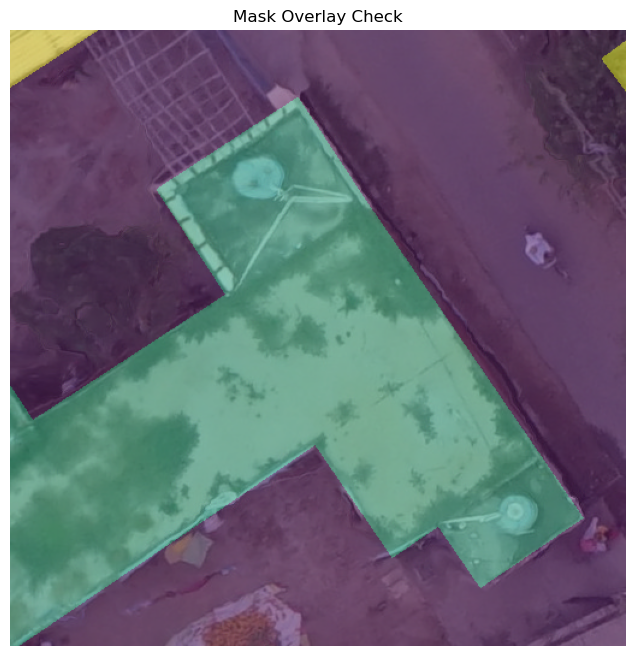


🧮 Pixel Count by Class: {np.uint8(0): np.int64(161837), np.uint8(3): np.int64(98090), np.uint8(5): np.int64(2217)}


In [5]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

# ======================
# Correct folder paths
# ======================
BASE_DIR = os.getcwd()  # Theme 1/
IMG_DIR = os.path.join(BASE_DIR, "processed_tiles", "images", "punjab" )
MASK_DIR = os.path.join(BASE_DIR, "processed_tiles", "masks", "punjab")

print("📌 Checking tiles in:", IMG_DIR)

# Pick a random tile pair for checking
img_files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".png")])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith(".png")])

# Ensure lists are not empty
if not img_files or not mask_files:
    print("❌ No tiles found. Run tiling first!")
else:
    sample = min(len(img_files), len(mask_files))
    idx = random.randint(0, sample - 1)

    img_path = os.path.join(IMG_DIR, img_files[idx])
    mask_path = os.path.join(MASK_DIR, mask_files[idx])

    print("🖼 Image:", img_files[idx])
    print("🎯 Mask:", mask_files[idx])

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    # ------------------------
    # Unique class check
    # ------------------------
    print("\n📊 Unique Pixel Values in Mask:", np.unique(mask))

    # ------------------------
    # Overlay Visualization
    # ------------------------
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.imshow(mask, alpha=0.45)   # see mask alignment
    plt.axis("off")
    plt.title("Mask Overlay Check")
    plt.show()

    # ------------------------
    # Class pixel counts
    # ------------------------
    unique, counts = np.unique(mask, return_counts=True)
    print("\n🧮 Pixel Count by Class:", dict(zip(unique, counts)))
